# Exoplanet Mass Determination for 55 Cancri
**Ethan Eng and Tony Kuang** 

### Step 2

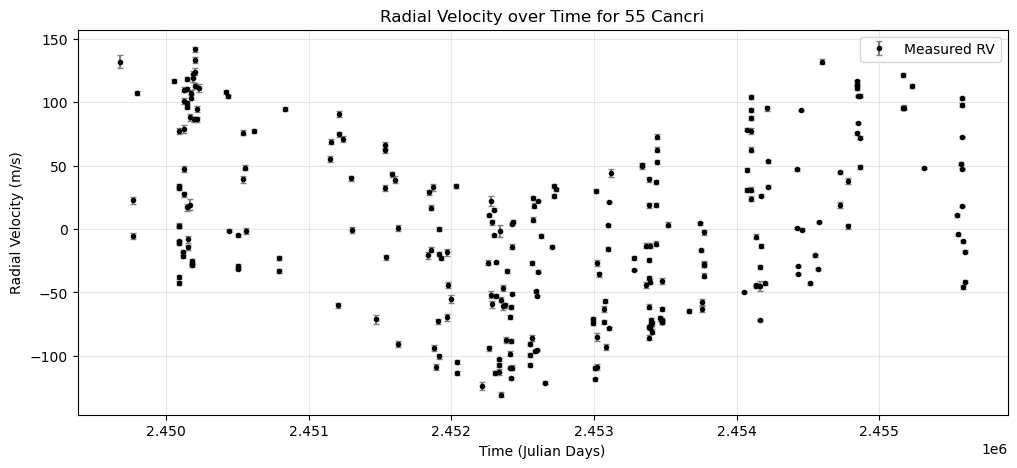

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

file_name = 'UID_0043587_RVC_008.tbl.txt'
df = pd.read_csv(file_name, sep=r'\s+', skiprows=22, names=['Time', 'RV', 'Error'])

plt.figure(figsize=(12, 5))
plt.errorbar(df['Time'], df['RV'], yerr=df['Error'], 
             fmt='o', markersize=3, color='black', ecolor='gray', capsize=2, label='Measured RV')

plt.title('Radial Velocity over Time for 55 Cancri')
plt.xlabel('Time (Julian Days)')
plt.ylabel('Radial Velocity (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 3: Using `curve_fit`, we determined the best-fit parameters for amplitude, period, phase, and velocity offset.

In [2]:
t = df['Time'] - df['Time'].min()

def rv_model(t, k, p, phi, c):
    return k * np.sin(2*np.pi*t/p + phi) + c

### k = amplitude of signal (m/s)
### p = orbital period (days)
### phi = phase
### c = constant offset

Best-fit parameters:
Amplitude K = -11.102669117058094 m/s
Period P = 14.979891655388153 days
Phase phi = -3.4765960621967467 radians
Offset C = 0.667359259282269 m/s


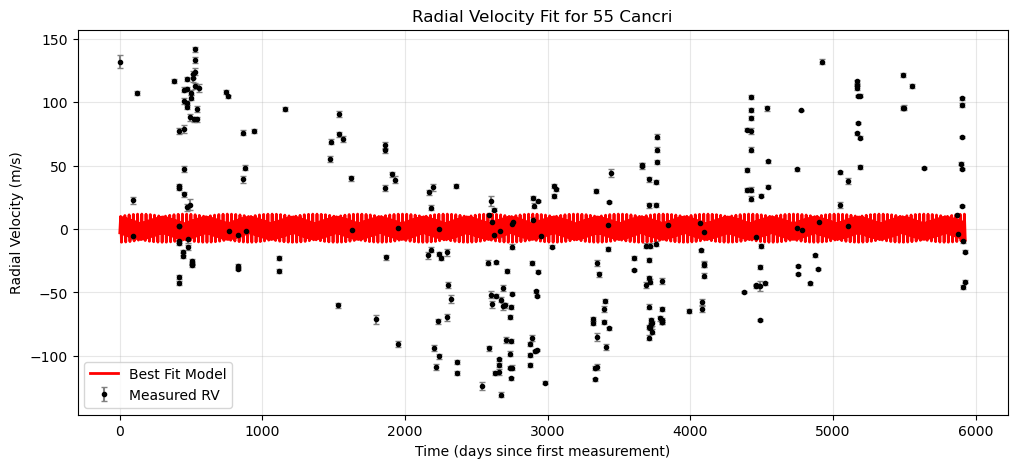

In [3]:
initial_guess = [60, 15, 0, 0]  

params, covariance = curve_fit(rv_model, t, df['RV'], sigma=df['Error'], p0=initial_guess, maxfev=10000)

K, P, phi, C = params
print("Best-fit parameters:")
print("Amplitude K =", K, "m/s")
print("Period P =", P, "days")
print("Phase phi =", phi, "radians")
print("Offset C =", C, "m/s")

t_fit = np.linspace(t.min(), t.max(), 1000)
rv_fit = rv_model(t_fit, K, P, phi, C)

plt.figure(figsize=(12,5))

plt.errorbar(t, df['RV'], yerr=df['Error'],
             fmt='o', markersize=3, color='black', ecolor='gray', capsize=2, label='Measured RV')

plt.plot(t_fit, rv_fit, color='red', linewidth=2, label='Best Fit Model')

plt.xlabel("Time (days since first measurement)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Fit for 55 Cancri")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 4

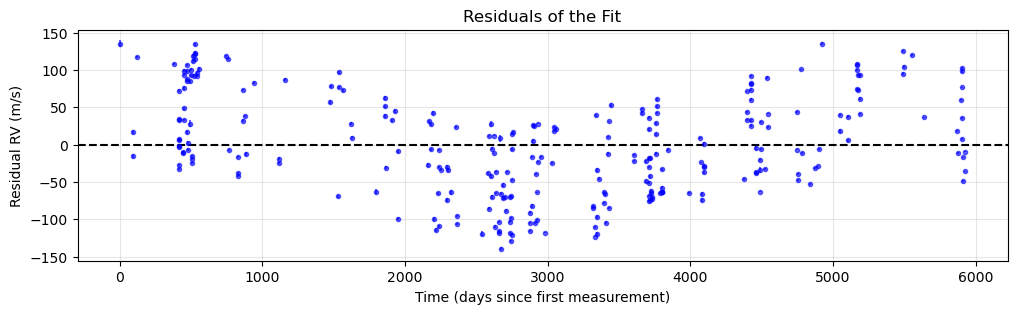

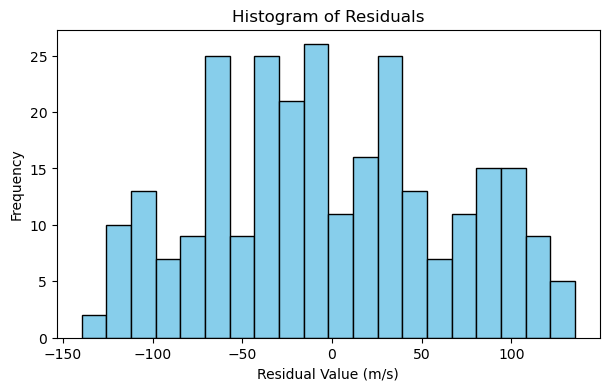

Standard Deviation of Residuals: 66.79 m/s
Average Assumed Experimental Error: 1.81 m/s


In [4]:
model_values = rv_model(t, K, P, phi, C)
residuals = df['RV'] - model_values

plt.figure(figsize=(12, 3))
plt.errorbar(t, residuals, yerr=df['Error'], fmt='o', markersize=3, color='blue', alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals of the Fit')
plt.xlabel('Time (days since first measurement)')
plt.ylabel('Residual RV (m/s)')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value (m/s)')
plt.ylabel('Frequency')
plt.show()

std_dev = np.std(residuals)
assumed_error = np.mean(df['Error'])

print(f"Standard Deviation of Residuals: {std_dev:.2f} m/s")
print(f"Average Assumed Experimental Error: {assumed_error:.2f} m/s")

# Step 5:

In [6]:
M_star = 0.905

M_planet = (K * (P**(1/3)) * (M_star**(2/3))) / 28.4

print(f"Estimated Mass of Exoplanet 55 Cancri b: {M_planet:.3f} Jupiter masses")

Estimated Mass of Exoplanet 55 Cancri b: -0.902 Jupiter masses


This calculation uses the **amplitude** and **period** obtained from our sinusoidal fit (Step 3) along with the known stellar mass. The result gives an estimate of the planet’s mass in Jupiter masses.